# Análise Exploratória de Dados (EDA)
Estatísticas descritivas.
Leitura inicial dos dados com exclusão de linhas com valores ausentes. A coluna 'Gross' foi ajustada para que seus valores sejam lidos como numéricos. Dos valores iniciais apresentados, apenas 713 serão usados para as análises a seguir.

In [1]:
import pandas as pd

file_path = 'data/desafio_indicium_imdb.csv'
df = pd.read_csv(file_path)
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)
df = df.dropna(axis=0)
df.describe()

,Unnamed: 0,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,713.000000,713.000000,713.000000,7.130000e+02,7.130000e+02
mean,519.300140,7.935203,77.154278,3.533480e+05,7.858395e+07
std,295.416331,0.288999,12.409392,3.462212e+05,1.150433e+08
min,1.000000,7.600000,28.000000,2.522900e+04,1.305000e+03
25%,263.000000,7.700000,70.000000,9.582600e+04,6.153939e+06
50%,527.000000,7.900000,78.000000,2.363110e+05,3.500000e+07
75%,778.000000,8.100000,86.000000,5.059180e+05,1.025158e+08
max,997.000000,9.200000,100.000000,2.303232e+06,9.366622e+08


In [ ]:
df.head()

,Unnamed: 0,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
1,2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
2,3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
3,4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0
4,5,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,377845905.0


Resultados por coluna (Mediana e Moda)

In [ ]:
mediana_imdb = df['IMDB_Rating'].median()
moda_imdb = df['IMDB_Rating'].mode()[0]

mediana_meta = df['Meta_score'].median()
moda_meta = df['Meta_score'].mode()[0]

mediana_votes = df['No_of_Votes'].median()
moda_votes = df['No_of_Votes'].mode()[0]

mediana_gross = df['Gross'].median()
moda_gross = df['Gross'].mode()[0]

print("IMDB_Rating: Mediana -", mediana_imdb, ", Moda -", moda_imdb)
print("Meta_score: Mediana -", mediana_meta, ", Moda -", moda_meta)
print("No_of_Votes: Mediana -", mediana_votes, ", Moda -", moda_votes)
print("Gross: Mediana -", mediana_gross, ", Moda -", moda_gross)

IMDB_Rating: Mediana - 7.9 , Moda - 7.7
Meta_score: Mediana - 78.0 , Moda - 76.0
No_of_Votes: Mediana - 236311.0 , Moda - 25229
Gross: Mediana - 35000000.0 , Moda - 4360000.0


Análise de Correlação (colunas numéricas):
Correlação: Uma correlação próxima de 1 ou -1 indica uma relação forte, enquanto uma correlação próxima de 0 indica uma relação fraca. No caso abaixo, apresentou correlação moderada.

In [ ]:
num_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']
correlation = df[num_cols].corr()
print(correlation)

             IMDB_Rating  Meta_score  No_of_Votes     Gross
IMDB_Rating     1.000000    0.283745     0.609239  0.130857
Meta_score      0.283745    1.000000     0.028578 -0.014663
No_of_Votes     0.609239    0.028578     1.000000  0.560955
Gross           0.130857   -0.014663     0.560955  1.000000


Análise de Correlação (colunas categóricas):
Análise envolvendo todas as variáveis do banco de dados. Com exceção das exibidas no exemplo anterior, não mostrou nenhuma correlação relevante.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

colunas_categoricas = df.select_dtypes(include=['object']).columns
encoder = OrdinalEncoder()
df[colunas_categoricas] = encoder.fit_transform(df[colunas_categoricas])

matriz_correlacao = df.corr()
print(matriz_correlacao)

               Unnamed: 0  Series_Title  Released_Year  Certificate   Runtime  \
Unnamed: 0       1.000000      0.000523       0.095368     0.033259 -0.049626   
Series_Title     0.000523      1.000000      -0.009876     0.008030  0.049546   
Released_Year    0.095368     -0.009876       1.000000     0.195122 -0.059068   
Certificate      0.033259      0.008030       0.195122     1.000000  0.011594   
Runtime         -0.049626      0.049546      -0.059068     0.011594  1.000000   
Genre           -0.041849     -0.051939      -0.125096    -0.149940 -0.037385   
IMDB_Rating     -0.943267      0.015936      -0.179579    -0.070642  0.076282   
Overview         0.022394      0.060300       0.085206    -0.000082  0.089508   
Meta_score      -0.283182      0.003297      -0.267969    -0.064919  0.061783   
Director         0.018608     -0.018345      -0.025585     0.033641  0.114856   
Star1           -0.030815      0.006315       0.008381     0.039664  0.032777   
Star2           -0.029942   

Visualizações:

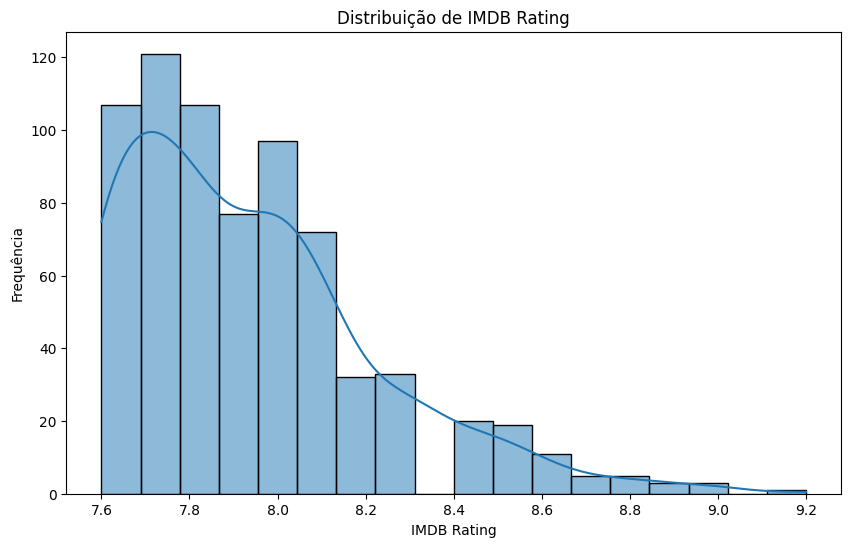

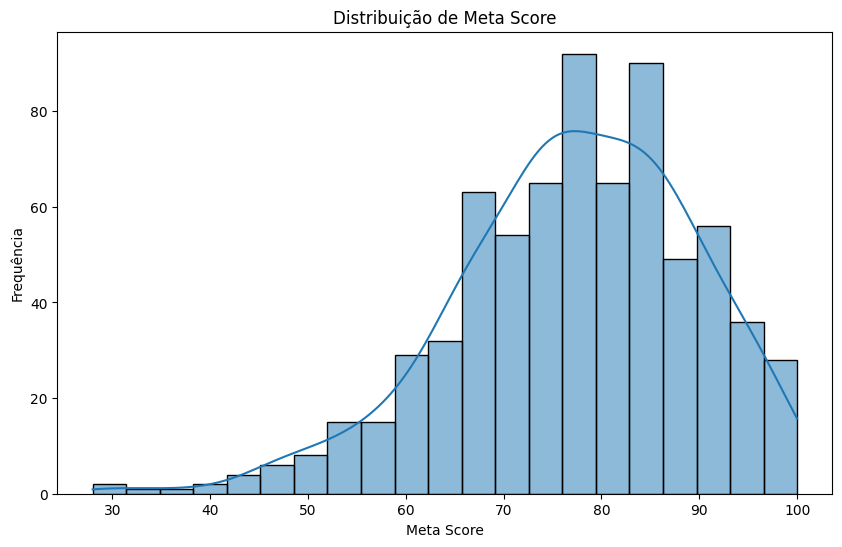

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para a coluna 'IMDB_Rating'
plt.figure(figsize=(10, 6))
sns.histplot(df['IMDB_Rating'], kde=True)
plt.title('Distribuição de IMDB Rating')
plt.xlabel('IMDB Rating')
plt.ylabel('Frequência')
plt.show()

# Histograma para a coluna 'Meta_score'
plt.figure(figsize=(10, 6))
sns.histplot(df['Meta_score'], kde=True)
plt.title('Distribuição de Meta Score')
plt.xlabel('Meta Score')
plt.ylabel('Frequência')
plt.show()


Análise de outliers com boxplot nas variáveis 'IMDB_Rating' e 'Meta_score'. Notas muito altas e muito baixas, respectivamente, foram consideradas como outliers e podem interferir nas análises.

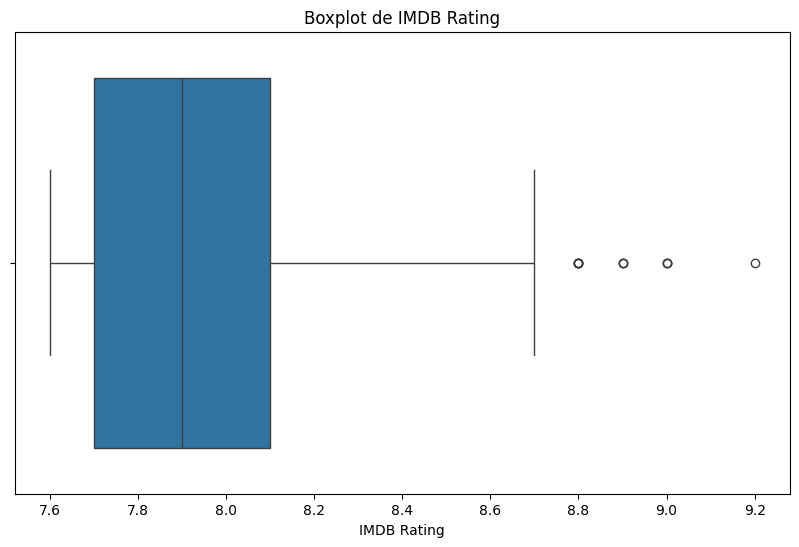

   Unnamed: 0                                   Series_Title Released_Year  \
0           1                                  The Godfather          1972   
1           2                                The Dark Knight          2008   
2           3                         The Godfather: Part II          1974   
3           4                                   12 Angry Men          1957   
4           5  The Lord of the Rings: The Return of the King          2003   
5           6                                   Pulp Fiction          1994   
6           7                               Schindler's List          1993   

  Certificate  Runtime                      Genre  IMDB_Rating  \
0           A  175 min               Crime, Drama          9.2   
1          UA  152 min       Action, Crime, Drama          9.0   
2           A  202 min               Crime, Drama          9.0   
3           U   96 min               Crime, Drama          9.0   
4           U  201 min   Action, Adventure, D

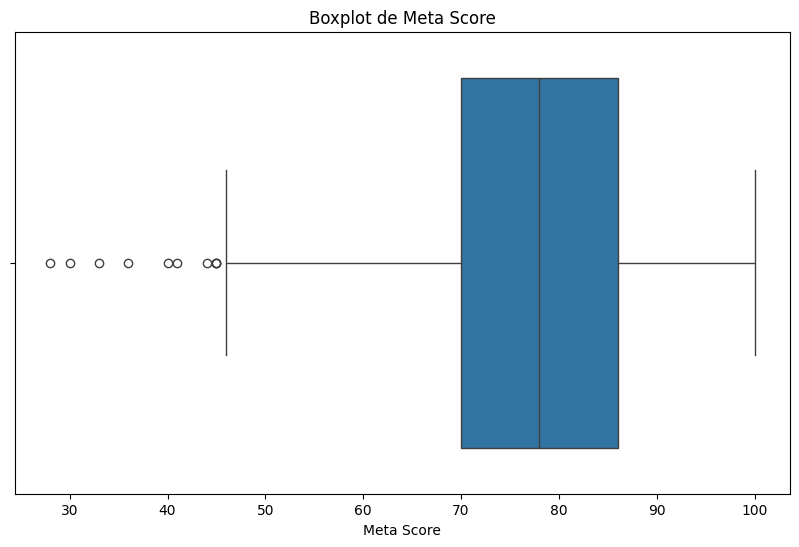

In [ ]:
from scipy import stats
import numpy as np

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['IMDB_Rating'])
plt.title('Boxplot de IMDB Rating')
plt.xlabel('IMDB Rating')
plt.show()

z_scores = np.abs(stats.zscore(df['IMDB_Rating']))
outliers = df[z_scores > 3]
print(outliers)

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Meta_score'])
plt.title('Boxplot de Meta Score')
plt.xlabel('Meta Score')
plt.show()


Análise de outliers utilizando cálculo de IQR (Intervalo Interquartil)

Outliers usando Z-Score:
   Unnamed: 0                                   Series_Title Released_Year  \
0           1                                  The Godfather          1972   
1           2                                The Dark Knight          2008   
2           3                         The Godfather: Part II          1974   
3           4                                   12 Angry Men          1957   
4           5  The Lord of the Rings: The Return of the King          2003   
5           6                                   Pulp Fiction          1994   
6           7                               Schindler's List          1993   

  Certificate  Runtime                      Genre  IMDB_Rating  \
0           A  175 min               Crime, Drama          9.2   
1          UA  152 min       Action, Crime, Drama          9.0   
2           A  202 min               Crime, Drama          9.0   
3           U   96 min               Crime, Drama          9.0   
4           U  201 m

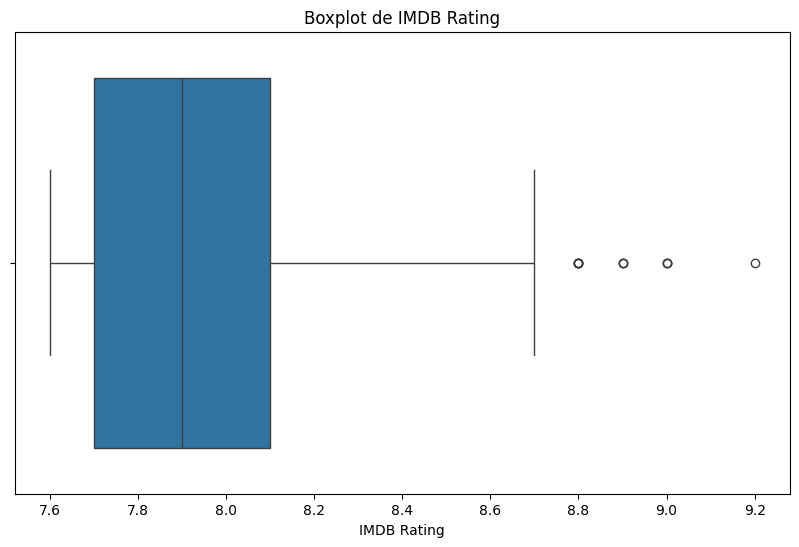

In [ ]:
z_scores = np.abs(stats.zscore(df['IMDB_Rating']))
outliers = df[z_scores > 3]
print("Outliers usando Z-Score:")
print(outliers)

Q1 = df['IMDB_Rating'].quantile(0.25)
Q3 = df['IMDB_Rating'].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df[(df['IMDB_Rating'] < (Q1 - 1.5 * IQR)) | (df['IMDB_Rating'] > (Q3 + 1.5 * IQR))]
print("Outliers usando IQR:")
print(outliers_iqr)

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['IMDB_Rating'])
plt.title('Boxplot de IMDB Rating')
plt.xlabel('IMDB Rating')
plt.show()

Divisão de gênero por filmes para melhor visualizar informações sobre essa variável.

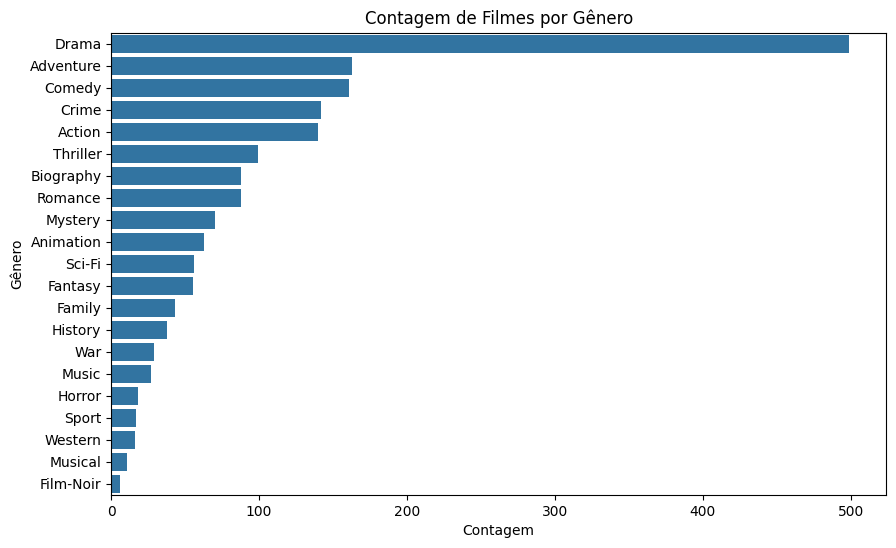

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Genre'] = df['Genre'].apply(lambda x: x.split(', '))
df_exploded = df.explode('Genre')
genre_counts = df_exploded['Genre'].value_counts()

plt.figure(figsize=(10, 6))
sns.countplot(y=df_exploded['Genre'], order=genre_counts.index)
plt.title('Contagem de Filmes por Gênero')
plt.xlabel('Contagem')
plt.ylabel('Gênero')
plt.show()


Cálculo de algumas médias ao decorrer dos anos. A escolha foi feita apresentando apenas os cinco principais gêneros para facilitar a visualização das informações geradas. Alguns prints foram colocados para garantir que as informações iniciais estavam corretas e não recebia uma lista vazia.

Top 5 gêneros: Index(['Adventure', 'Drama', 'Action', 'Comedy', 'Sci-Fi'], dtype='object', name='Genre')
Quantidade de filmes nos top 5 gêneros: 1019
  Released_Year      Genre  IMDB_Rating  No_of_Votes       Gross
0          1930      Drama          8.0      57318.0   3270000.0
1          1931     Comedy          8.5     167839.0     19181.0
2          1931      Drama          8.5     167839.0     19181.0
3          1933  Adventure          7.9      78991.0  10000000.0
4          1933     Sci-Fi          7.9      78991.0  10000000.0


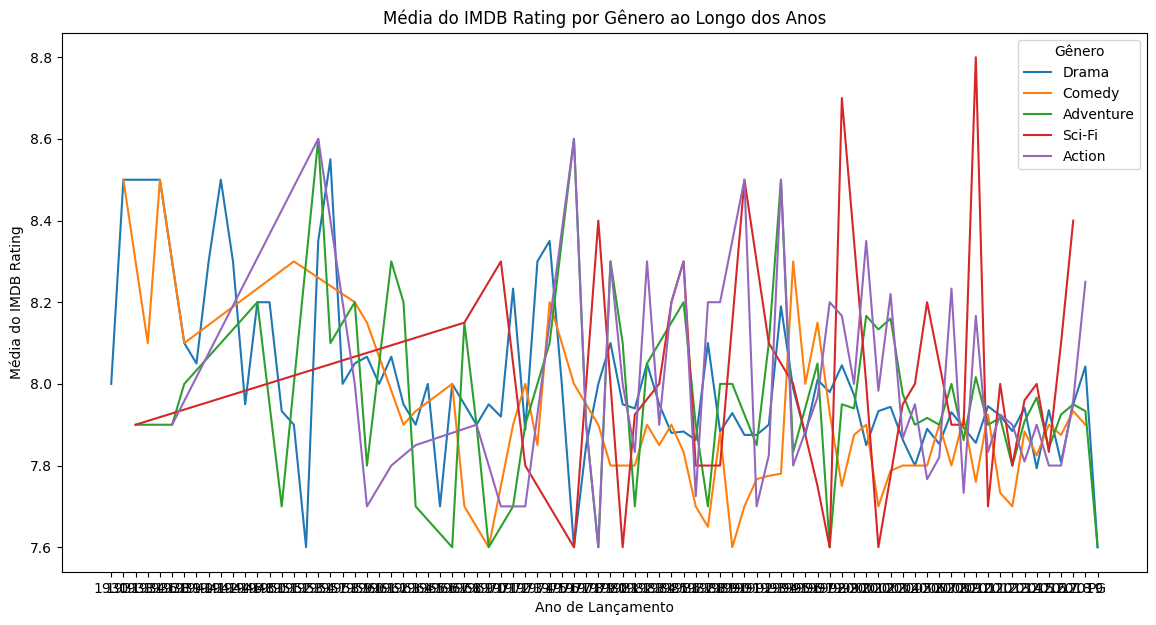

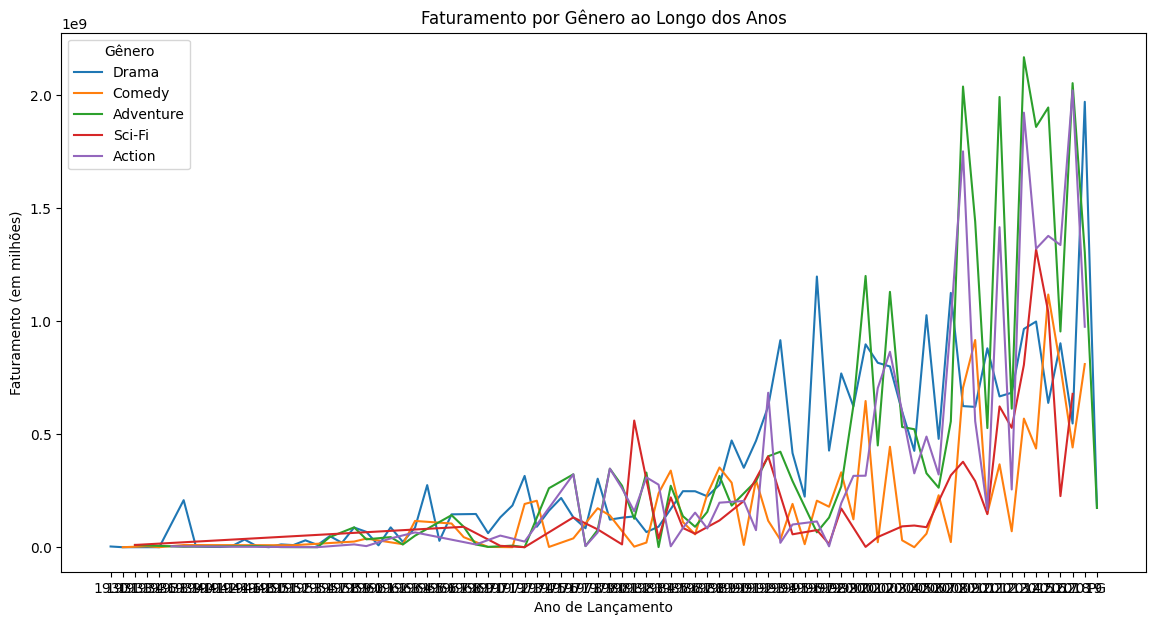

In [4]:
top_genres = df_exploded.groupby('Genre')['Gross'].sum().nlargest(5).index
print("Top 5 gêneros:", top_genres)

df_top_genres = df_exploded[df_exploded['Genre'].isin(top_genres)]
print("Quantidade de filmes nos top 5 gêneros:", len(df_top_genres))

grouped = df_top_genres.groupby(['Released_Year', 'Genre']).agg({
    'IMDB_Rating': 'mean',
    'No_of_Votes': 'mean',
    'Gross': 'sum'
}).reset_index()
print(grouped.head())

plt.figure(figsize=(14, 7))
sns.lineplot(data=grouped, x='Released_Year', y='IMDB_Rating', hue='Genre')
plt.title('Média do IMDB Rating por Gênero ao Longo dos Anos')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Média do IMDB Rating')
plt.legend(title='Gênero')
plt.show()

plt.figure(figsize=(14, 7))
sns.lineplot(data=grouped, x='Released_Year', y='Gross', hue='Genre')
plt.title('Faturamento por Gênero ao Longo dos Anos')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Faturamento (em milhões)')
plt.legend(title='Gênero')
plt.show()

<ipython-input-20-461d2b3a61da>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_ratings.index, y=genre_ratings.values, palette='viridis')


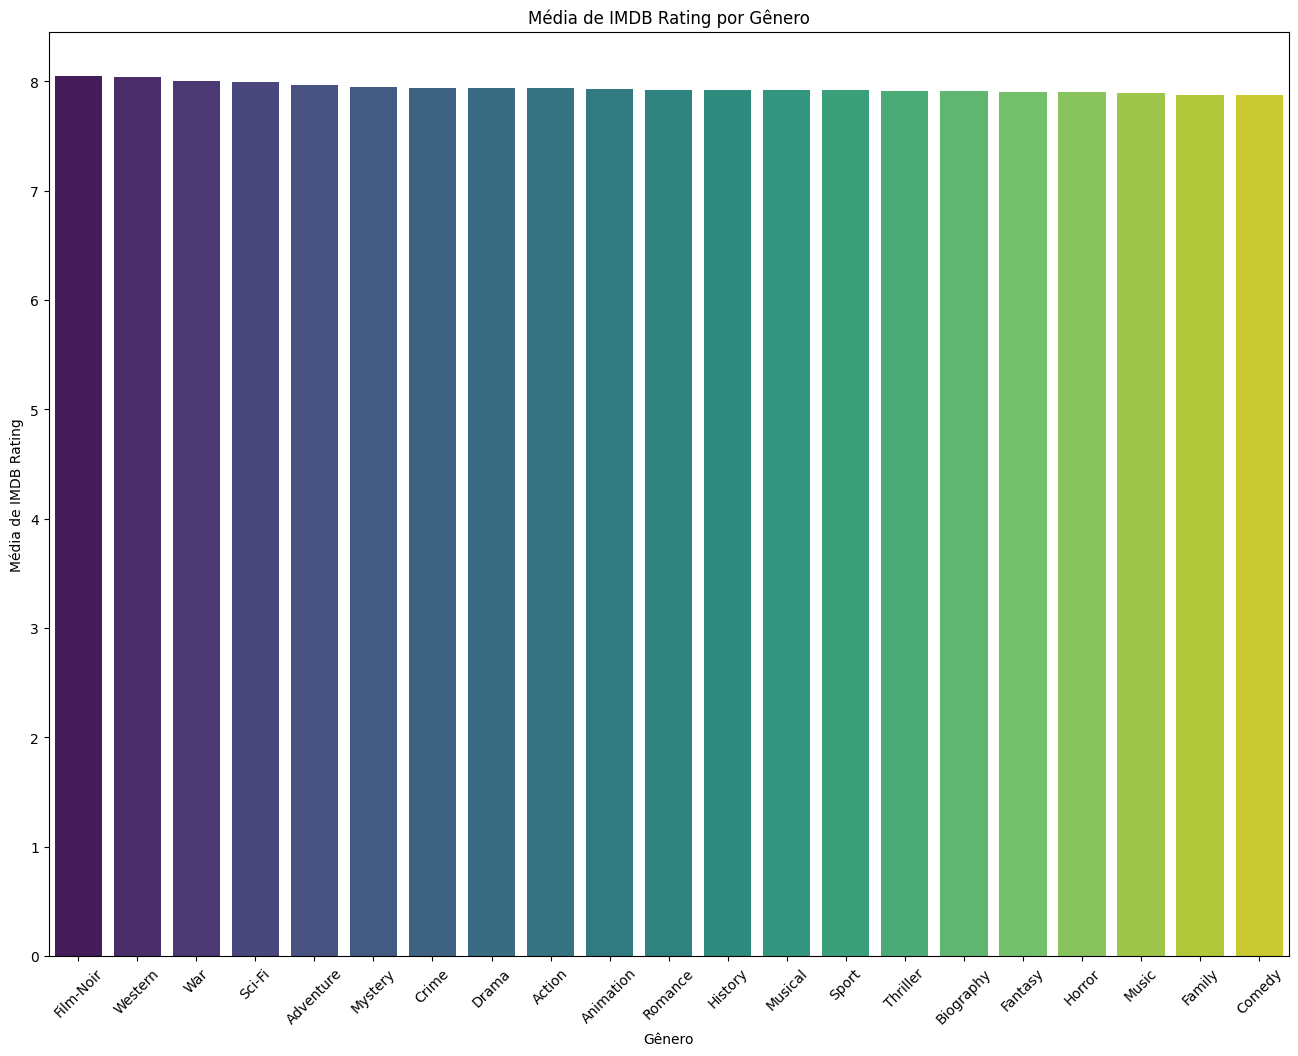

<ipython-input-20-461d2b3a61da>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_gross.index, y=genre_gross.values, palette='magma')


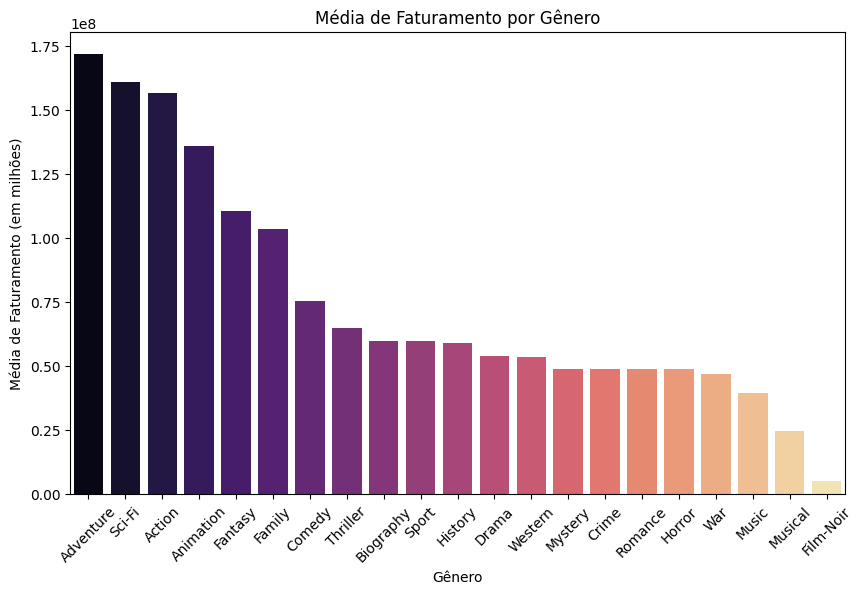

<Figure size 1400x1000 with 0 Axes>

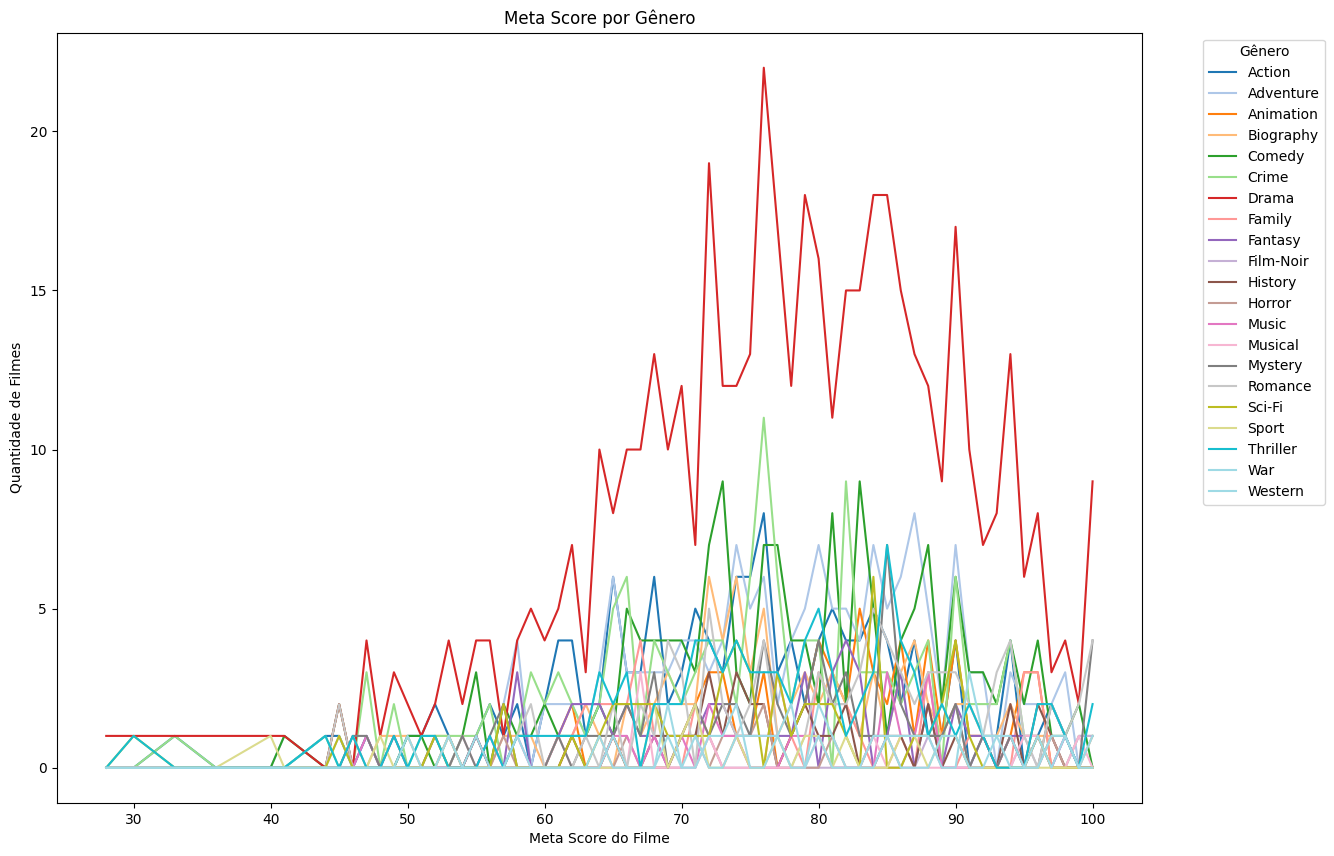

In [ ]:
genre_ratings = df_exploded.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 12))
sns.barplot(x=genre_ratings.index, y=genre_ratings.values, palette='viridis')
plt.title('Média de IMDB Rating por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Média de IMDB Rating')
plt.xticks(rotation=45)
plt.show()

genre_gross = df_top_genres.groupby('Genre')['Gross'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_gross.index, y=genre_gross.values, palette='magma')
plt.title('Média de Faturamento por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Média de Faturamento (em milhões)')
plt.xticks(rotation=45)
plt.show()

genre_year_count = df_top_genres.groupby(['Meta_score', 'Genre']).size().unstack().fillna(0)

plt.figure(figsize=(14, 10))
genre_year_count.plot(kind='line', stacked=False, colormap='tab20', figsize=(14, 10))
plt.title('Meta Score por Gênero')
plt.xlabel('Meta Score do Filme')
plt.ylabel('Quantidade de Filmes')
plt.legend(title='Gênero', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Função auxiliar criada para calcular possíveis métricas de sucesso que foram aplicadas para gerar os gráficos seguintes. Atores foram agrupados para facilitar a visualização dos dados considerando que um mesmo nome poderia aparecer nas quatro variáveis relacionadas aos artistas.

<ipython-input-23-aa23ffd466bc>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_IMDB_Rating', y='Director', data=top_directors_by_rating, palette='viridis')


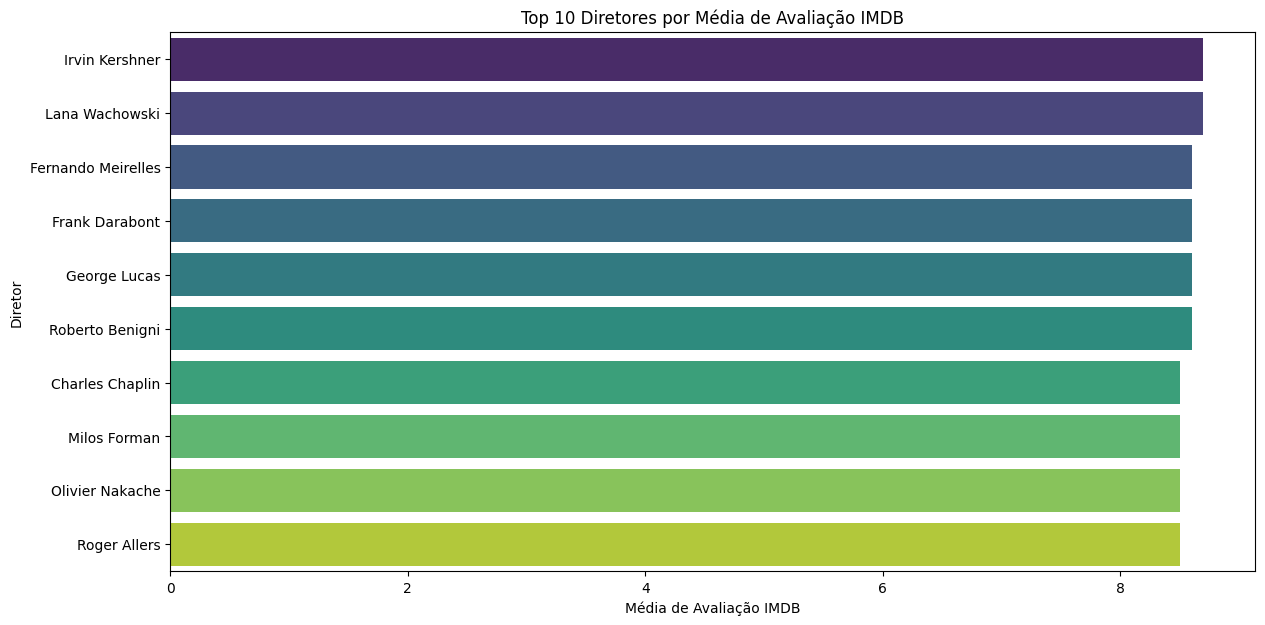

<ipython-input-23-aa23ffd466bc>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Gross', y='Director', data=top_directors_by_gross, palette='viridis')


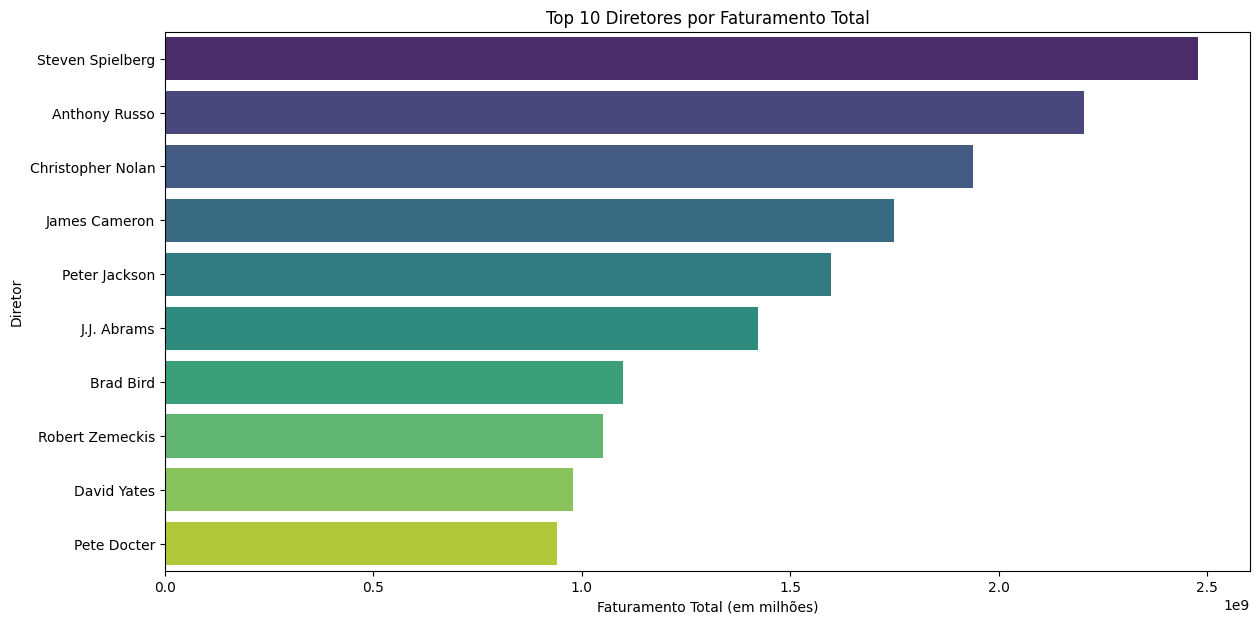

<ipython-input-23-aa23ffd466bc>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_IMDB_Rating', y='Star', data=top_actors_by_rating, palette='viridis')


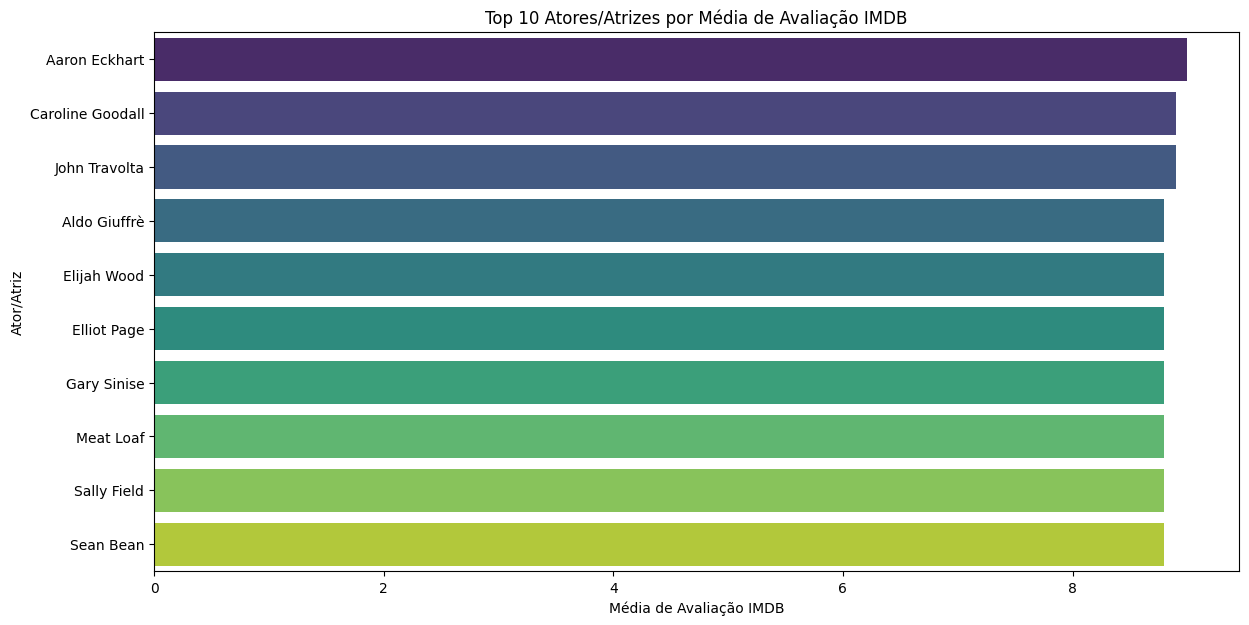

<ipython-input-23-aa23ffd466bc>:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Gross', y='Star', data=top_actors_by_gross, palette='viridis')


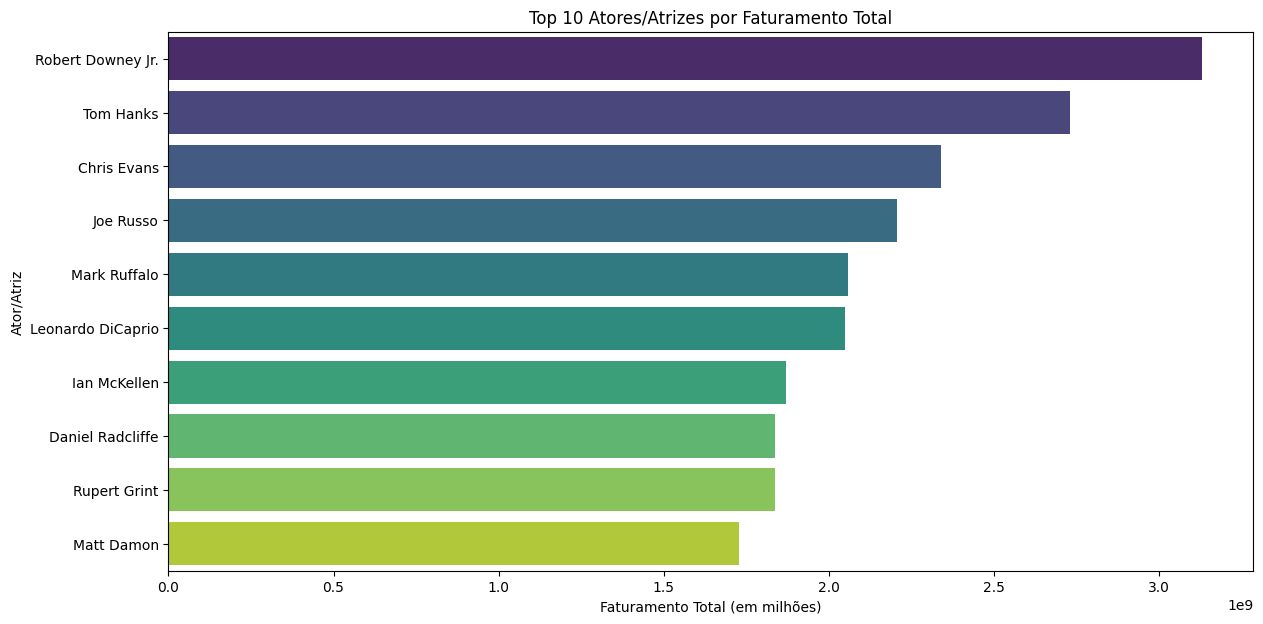

In [ ]:
def calculate_success_metrics(group):
    return pd.Series({
        'Avg_IMDB_Rating': group['IMDB_Rating'].mean(),
        'Total_Gross': group['Gross'].sum(),
        'Total_Votes': group['No_of_Votes'].sum(),
        'Movie_Count': group['Series_Title'].count()
    })

directors_grouped = df_exploded.groupby('Director').apply(calculate_success_metrics).reset_index()

actors_grouped = pd.concat([
    df_exploded.groupby('Star1').apply(calculate_success_metrics).reset_index().rename(columns={'Star1': 'Star'}),
    df_exploded.groupby('Star2').apply(calculate_success_metrics).reset_index().rename(columns={'Star2': 'Star'}),
    df_exploded.groupby('Star3').apply(calculate_success_metrics).reset_index().rename(columns={'Star3': 'Star'}),
    df_exploded.groupby('Star4').apply(calculate_success_metrics).reset_index().rename(columns={'Star4': 'Star'})
]).groupby('Star').agg({
    'Avg_IMDB_Rating': 'mean',
    'Total_Gross': 'sum',
    'Total_Votes': 'sum',
    'Movie_Count': 'sum'
}).reset_index()

top_directors_by_rating = directors_grouped.nlargest(10, 'Avg_IMDB_Rating')

plt.figure(figsize=(14, 7))
sns.barplot(x='Avg_IMDB_Rating', y='Director', data=top_directors_by_rating, palette='viridis')
plt.title('Top 10 Diretores por Média de Avaliação IMDB')
plt.xlabel('Média de Avaliação IMDB')
plt.ylabel('Diretor')
plt.show()

top_directors_by_gross = directors_grouped.nlargest(10, 'Total_Gross')

plt.figure(figsize=(14, 7))
sns.barplot(x='Total_Gross', y='Director', data=top_directors_by_gross, palette='viridis')
plt.title('Top 10 Diretores por Faturamento Total')
plt.xlabel('Faturamento Total (em milhões)')
plt.ylabel('Diretor')
plt.show()

top_actors_by_rating = actors_grouped.nlargest(10, 'Avg_IMDB_Rating')

plt.figure(figsize=(14, 7))
sns.barplot(x='Avg_IMDB_Rating', y='Star', data=top_actors_by_rating, palette='viridis')
plt.title('Top 10 Atores/Atrizes por Média de Avaliação IMDB')
plt.xlabel('Média de Avaliação IMDB')
plt.ylabel('Ator/Atriz')
plt.show()

top_actors_by_gross = actors_grouped.nlargest(10, 'Total_Gross')

plt.figure(figsize=(14, 7))
sns.barplot(x='Total_Gross', y='Star', data=top_actors_by_gross, palette='viridis')
plt.title('Top 10 Atores/Atrizes por Faturamento Total')
plt.xlabel('Faturamento Total (em milhões)')
plt.ylabel('Ator/Atriz')
plt.show()


Agrupamento de diretores com vários filmes para melhor visualizar suas avaliações no IMDB.

<ipython-input-5-32a273ad17a2>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_directors_ratings.values, y=top_15_directors_ratings.index, palette='coolwarm')


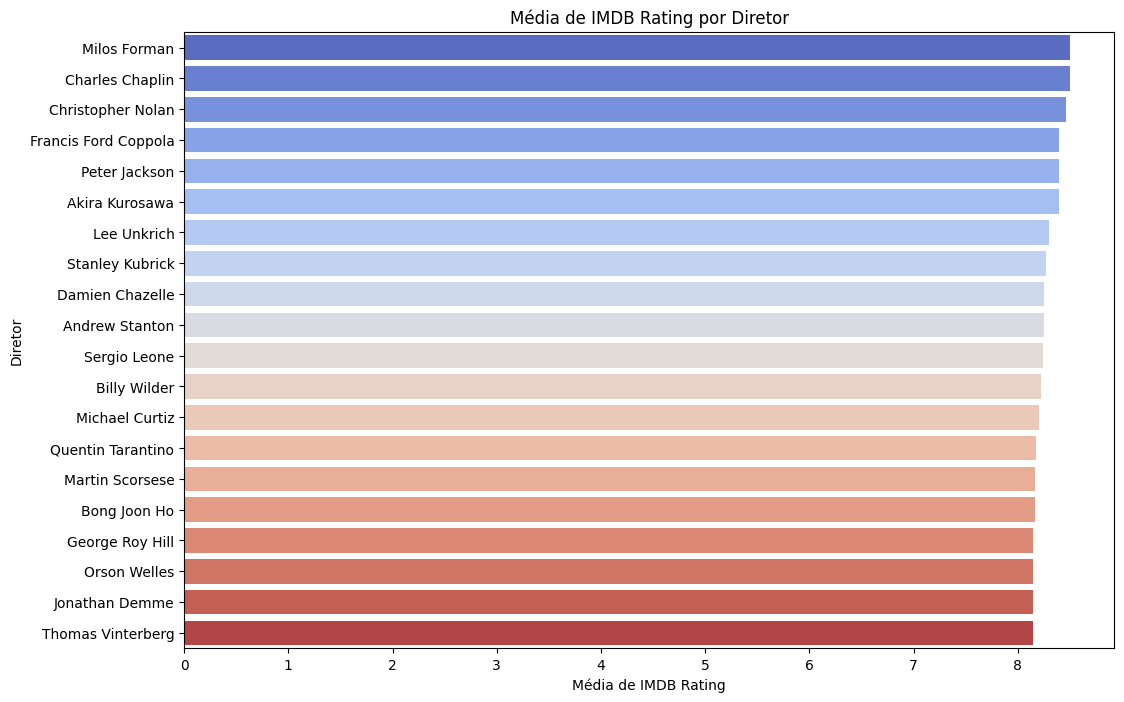

In [5]:
director_ratings = df.groupby('Director')['IMDB_Rating'].mean().sort_values(ascending=False)

director_counts = df['Director'].value_counts()
directors_with_multiple_films = director_counts[director_counts > 1].index
director_ratings = director_ratings[director_ratings.index.isin(directors_with_multiple_films)]
top_15_directors_ratings = director_ratings.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_directors_ratings.values, y=top_15_directors_ratings.index, palette='coolwarm')
plt.title('Média de IMDB Rating por Diretor')
plt.xlabel('Média de IMDB Rating')
plt.ylabel('Diretor')
plt.show()

O mesmo agrupamento utilizado anteriormente foi utilizado aqui para verificar suas avaliações no Metascore. Novamente, apenas alguns resultados foram exibidos para facilitar a visualização.

<ipython-input-55-dd10ab67dfe3>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_directors_ratings.values, y=top_15_directors_ratings.index, palette='viridis')


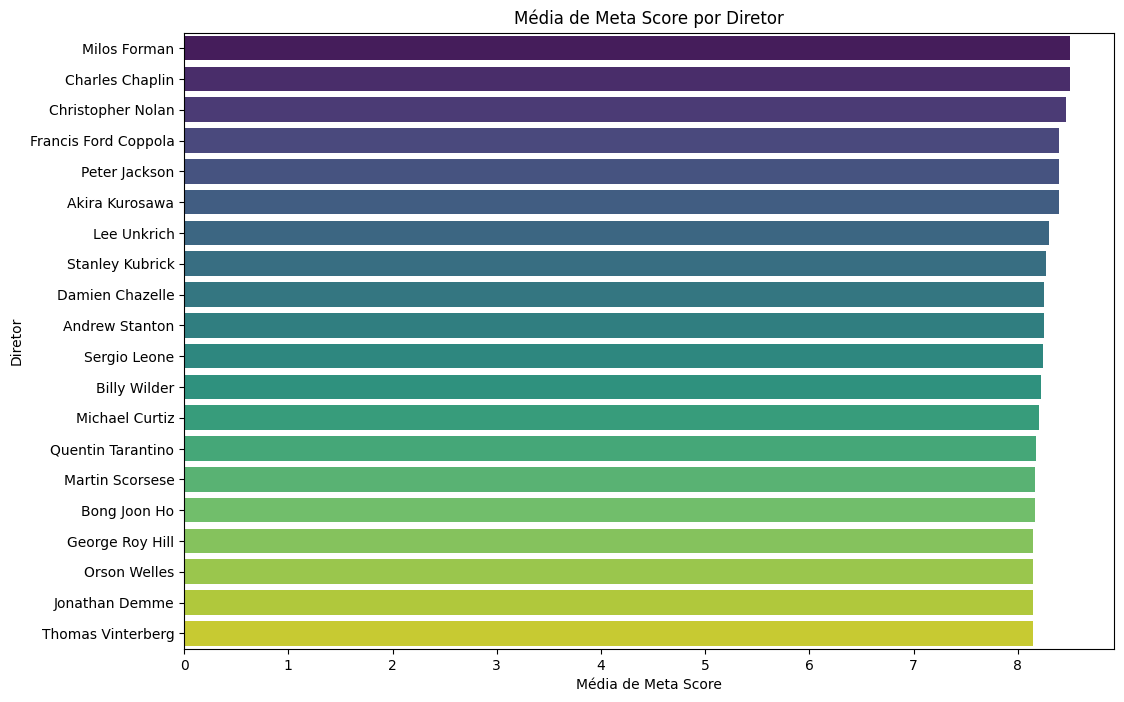

In [ ]:
director_meta_scores = df.groupby('Director')['Meta_score'].mean().sort_values(ascending=False)

director_meta_scores = director_meta_scores[director_meta_scores.index.isin(directors_with_multiple_films)]
top_15_directors_ratings = director_ratings.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_directors_ratings.values, y=top_15_directors_ratings.index, palette='viridis')
plt.title('Média de Meta Score por Diretor')
plt.xlabel('Média de Meta Score')
plt.ylabel('Diretor')
plt.show()

Visualização de faturamento por diretor.

<ipython-input-6-04f410005d90>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_directors_gross.values, y=top_15_directors_gross.index, palette='coolwarm')


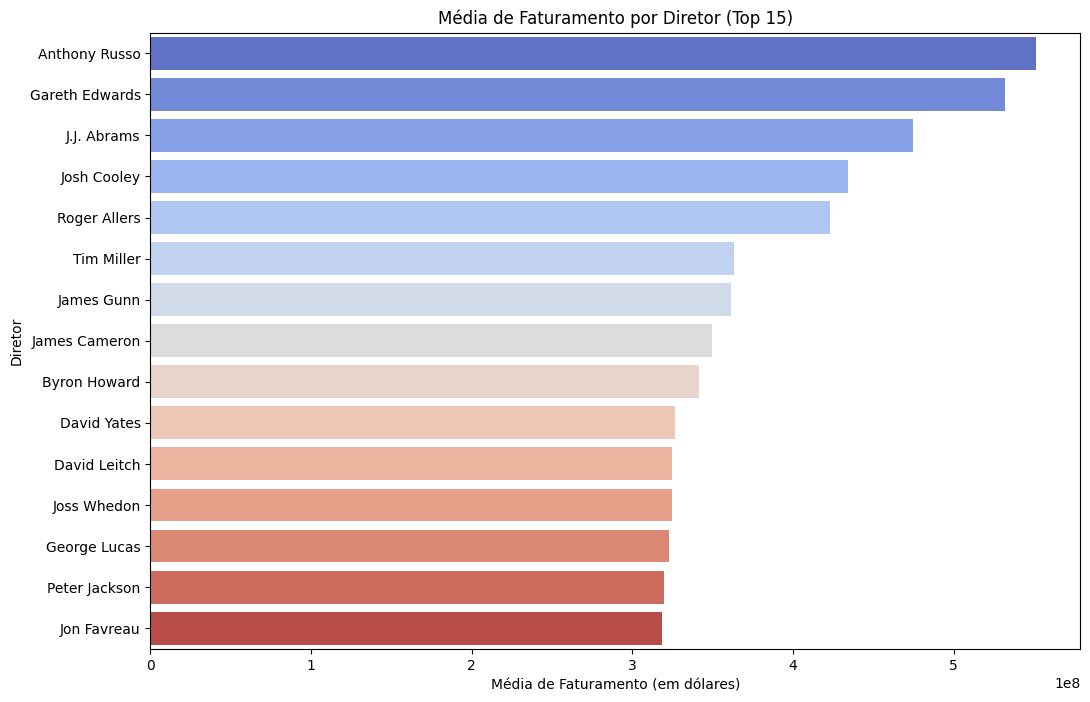

In [6]:
director_gross = df.groupby('Director')['Gross'].mean().sort_values(ascending=False)
top_15_directors_gross = director_gross.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_directors_gross.values, y=top_15_directors_gross.index, palette='coolwarm')
plt.title('Média de Faturamento por Diretor (Top 15)')
plt.xlabel('Média de Faturamento (em dólares)')
plt.ylabel('Diretor')
plt.show()
